# SIT720 8.1D Sydney Housing Price Prediction


In [94]:
# %pip install "pandas>=2.2,<4" "numpy>=2,<3" "scipy>=1.14,<2" "matplotlib>=3.10,<4" "gradio>=6,<7"


## 1. Load the data and preserve the evaluation split
Detailed price EDA uses 92 development records. Ten records remain reserved for later evaluation. Part 1 already summarised the full sample, so these are not wholly unseen from the start of the project.

In [95]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Image

ROOT = Path.cwd()
DATA_FILE = ROOT / 'data/sydney_housing_dataset.csv'
if not DATA_FILE.exists():
    raise FileNotFoundError('Place this notebook beside data/sydney_housing_dataset.csv and run from the project folder.')
OUT = ROOT / 'outputs/part2'
OUT.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_FILE)
df['sale_date'] = pd.to_datetime(df['sale_date'])
assert len(df) == 102 and df['property_id'].is_unique
assert (df['split'] == 'heldout').sum() == 10

display(pd.crosstab(df.suburb, df.split))
print('Total records:', len(df))

split,development,heldout
suburb,,
Chatswood,31,4
Parramatta,32,3
Penrith,29,3


Total records: 102


## Part 1 — Problem Definition and Data Collection

The prediction target is the disclosed sold price in Australian dollars. The selected suburbs represent contrasting markets: Chatswood combines high accessibility and premium prices, Parramatta is a major employment and apartment centre, and Penrith offers more outer-western house and land options. The canonical dataset was manually assembled from public sold-property pages and retains property-level source URLs and quality notes. Asking prices, estimates and rents are excluded.

The sample contains 102 standard residential transactions after two special cases were set aside. It meets the assignment threshold of at least 100 properties and at least 30 from each suburb. Convenience sampling, disclosed-price selection, uneven sale periods and different dwelling mixes limit representativeness. Agent descriptions are promotional sources, missing does not mean zero, and reported land/building/living/title areas are kept distinct.

In [96]:
part1_counts=df.groupby('suburb').size().rename('properties').to_frame()
part1_counts['minimum_30_met']=part1_counts['properties'].ge(30)
display(part1_counts)
assert len(df)>=100 and part1_counts['minimum_30_met'].all()
assert df['sale_price_aud'].gt(0).all()
assert df['source_url'].notna().all() and df['source_url'].is_unique
assert not df.duplicated(['suburb','address','sale_date']).any()
print('Dataset validation passed:', len(df), 'unique priced transactions and', df.shape[1], 'documented fields.')

,properties,minimum_30_met
suburb,,
Chatswood,35,True
Parramatta,35,True
Penrith,32,True


Dataset validation passed: 102 unique priced transactions and 38 documented fields.


## Part 2 — Data Understanding and Feature Engineering



# Expectations recorded before Part 2 feature engineering

Recorded September 2026, before running the Part 2 analysis cells. The Part 1 counts and sample medians were already known; this is not a claim of ignorance of all price data.

1. **Suburb:** location summarises accessibility, amenities and local demand. Expect higher prices in Chatswood, conditional on dwelling type, but do not interpret this as a causal effect.
2. **Property type:** houses and apartments offer different land interests, space and maintenance arrangements. Expect houses to command higher total prices within a suburb, with substantial overlap.
3. **Bedrooms:** bedroom count is an available proxy for accommodation capacity. Expect a positive association, conditional on location and type; it cannot measure room size or condition.

Land/internal area might be stronger with consistent measurement. It is not in the top three operational choices because the collected area fields are sparse and heterogeneous. No model-derived importance or engineered feature was used to choose these expectations.

Reserve 10 properties by suburb before further price exploration (4 Chatswood, 3 Parramatta, 3 Penrith; seed 720). Detailed Part 2 price analysis uses the remaining 92. Part 1 already described the full dataset, so the reserved set is held out from subsequent model fitting and detailed EDA, not wholly unseen throughout the project. Personal estimates must be obtained before showing the reserved actual prices to the student.


## 2. Prepare descriptive views
Unit and Apartment are harmonised for like-type comparisons; the source labels are preserved. Price conversion to millions is for display only. The substantive candidate-feature construction appears in Section 7.

In [97]:
df['property_type_group']=df.property_type.replace({'Unit':'Apartment'})
dev=df[df.split.eq('development')].copy()
dev['price_m']=dev.sale_price_aud/1e6
suburbs=['Chatswood','Parramatta','Penrith']; colors=dict(zip(suburbs,['#345995','#D17A22','#21867A']))
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':140,'savefig.dpi':180})
def save(fig,name):
    fig.savefig(OUT/f'{name}.png',bbox_inches='tight');fig.savefig(OUT/f'{name}.pdf',bbox_inches='tight');display(Image(filename=str(OUT/f'{name}.png')));plt.close(fig)

## 3. Price distribution and suburb comparisons

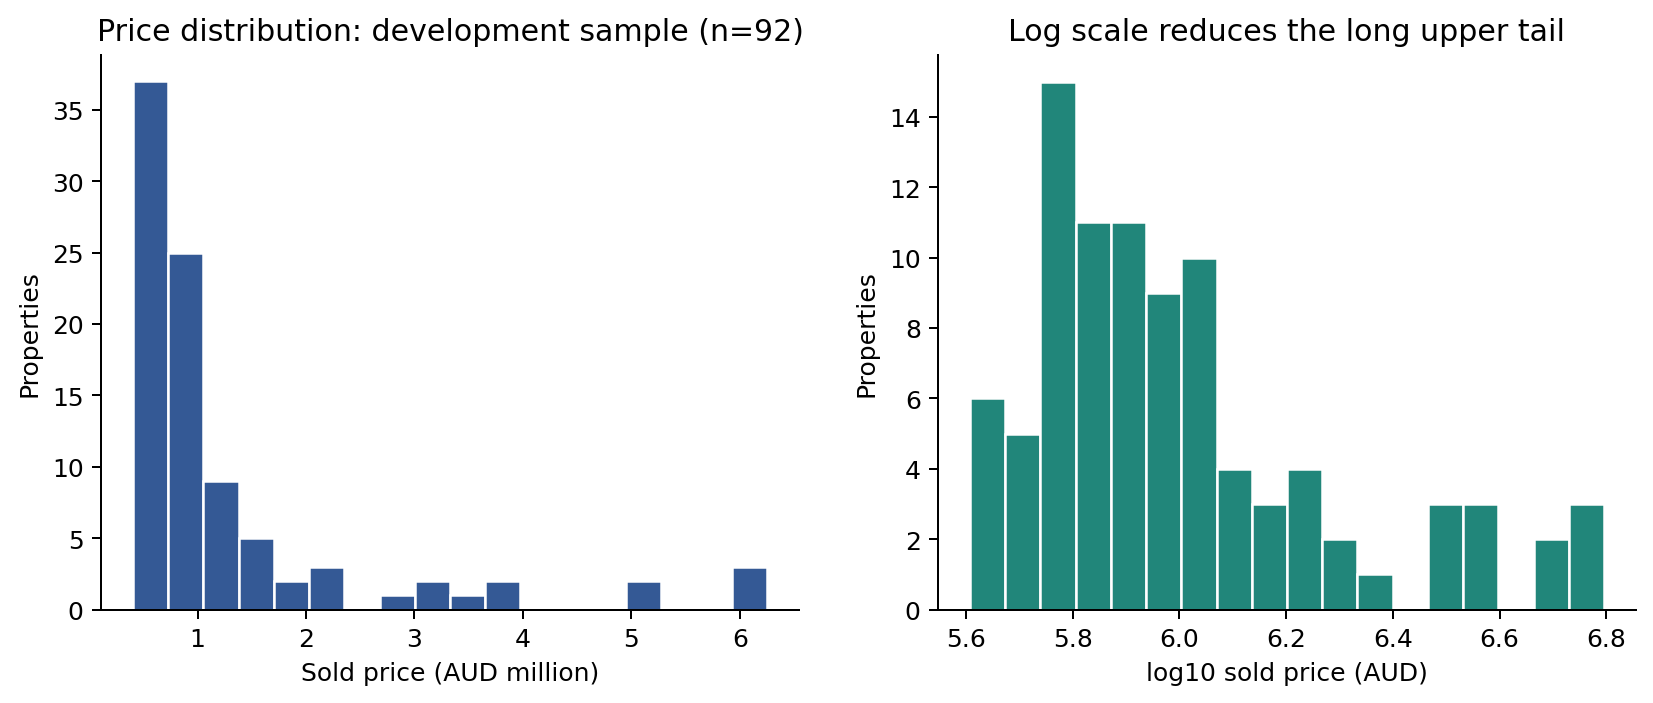

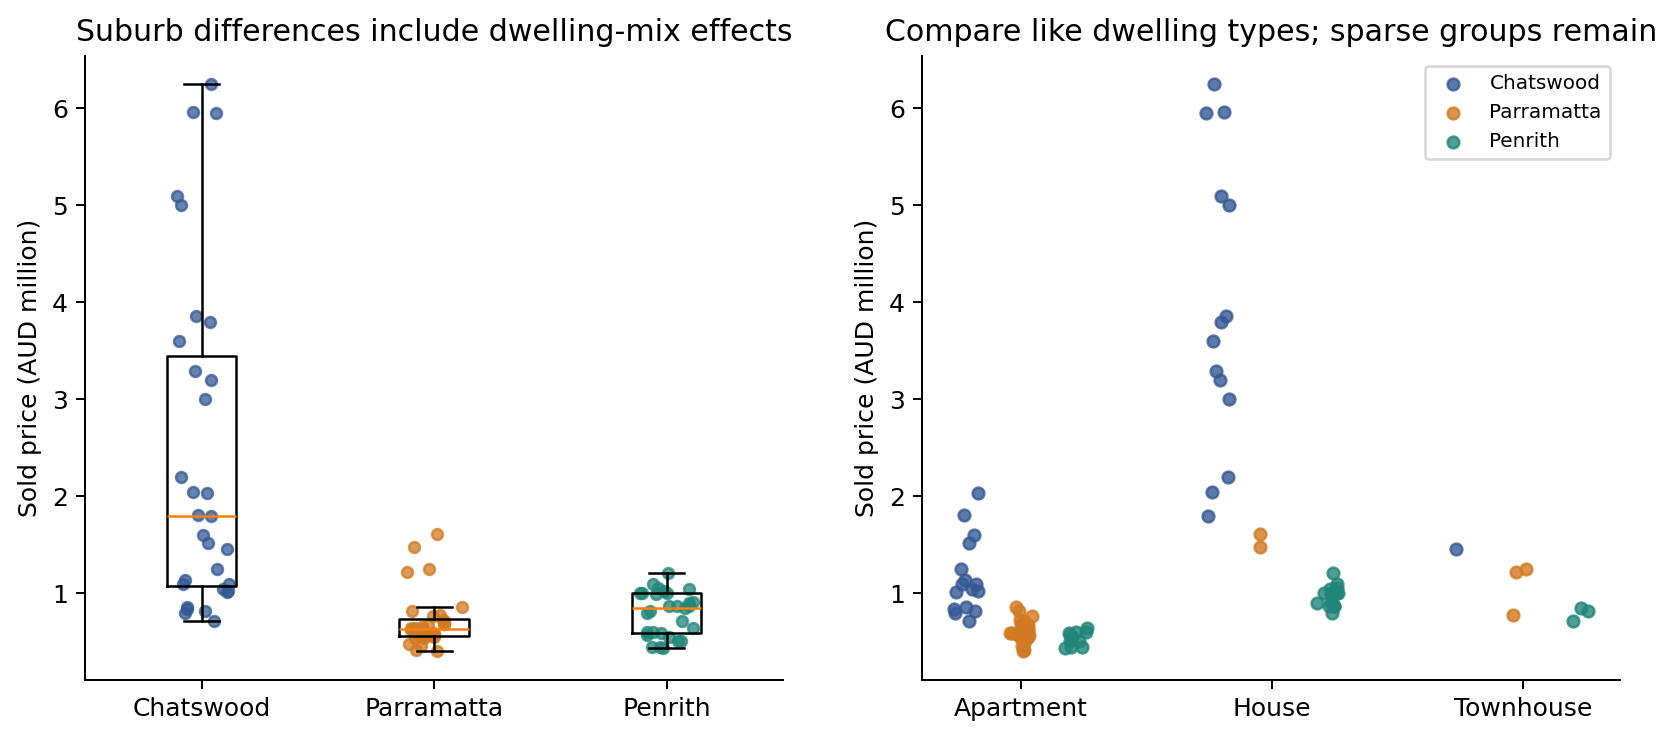

In [98]:
fig,axs=plt.subplots(1,2,figsize=(11,4))
axs[0].hist(dev.price_m,bins=18,color='#345995',edgecolor='white');axs[0].set(xlabel='Sold price (AUD million)',ylabel='Properties',title='Price distribution: development sample (n=92)')
axs[1].hist(np.log10(dev.sale_price_aud),bins=18,color='#21867A',edgecolor='white');axs[1].set(xlabel='log10 sold price (AUD)',ylabel='Properties',title='Log scale reduces the long upper tail')
save(fig,'01_price_distribution')
fig,axs=plt.subplots(1,2,figsize=(11,4.5));rng=np.random.default_rng(721)
axs[0].boxplot([dev.loc[dev.suburb.eq(s),'price_m'] for s in suburbs],tick_labels=suburbs,showfliers=False)
for i,s in enumerate(suburbs,1):
    y=dev.loc[dev.suburb.eq(s),'price_m'];axs[0].scatter(i+rng.uniform(-.12,.12,len(y)),y,c=colors[s],s=19,alpha=.75)
axs[0].set(ylabel='Sold price (AUD million)',title='Suburb differences include dwelling-mix effects')
types=['Apartment','House','Townhouse']
for i,s in enumerate(suburbs):
    g=dev[dev.suburb.eq(s)]
    for j,t in enumerate(types):
        y=g.loc[g.property_type_group.eq(t),'price_m'];x=j+(i-1)*.22
        axs[1].scatter(x+rng.uniform(-.05,.05,len(y)),y,c=colors[s],s=22,alpha=.8,label=s if j==0 else None)
axs[1].set(xticks=range(3),xticklabels=types,ylabel='Sold price (AUD million)',title='Compare like dwelling types; sparse groups remain')
axs[1].legend(fontsize=8);save(fig,'02_suburb_and_type')

In [99]:
summary=dev.groupby('suburb').sale_price_aud.agg(['count','mean','median','std','min','max']).reindex(suburbs)
summary.to_csv(OUT/'suburb_summary.csv')
type_summary=dev.groupby(['suburb','property_type_group']).sale_price_aud.agg(['count','median','min','max']);type_summary.to_csv(OUT/'suburb_type_summary.csv')

display(summary.round(2))
display(type_summary)
display(dev.sale_price_aud.agg(['mean','median','skew']).to_frame('AUD / skewness'))

,count,mean,median,std,min,max
suburb,,,,,,
Chatswood,31,2425738.71,1800000.0,1726154.31,720000,6250000
Parramatta,32,715687.50,637500.0,285470.12,405000,1610000
Penrith,29,791775.86,850000.0,226765.75,440000,1210000


count     median      min      max
suburb     property_type_group                                    
Chatswood  Apartment               16  1074000.0   720000  2036000
           House                   14  3700000.0  1800000  6250000
           Townhouse                1  1460000.0  1460000  1460000
Parramatta Apartment               27   600000.0   405000   855000
           House                    2  1545000.0  1480000  1610000
           Townhouse                3  1225000.0   780000  1250000
Penrith    Apartment               11   555000.0   440000   640000
           House                   15  1000000.0   802000  1210000
           Townhouse                3   820000.0   720000   850000

,AUD / skewness
mean,1.315885e+06
median,8.525000e+05
skew,2.475580e+00


**Interpretation.** Prices are right-skewed: mean AUD 1,315,885 versus median AUD 852,500, with skewness 2.48. Grouping by type changes suburb comparisons: Parramatta has a lower overall median than Penrith, but higher within-type medians. The two Parramatta houses and single Chatswood townhouse are too sparse for confident market generalisation. The logarithmic view compresses the tail without proving normality.

## 4. Examine time patterns and coverage

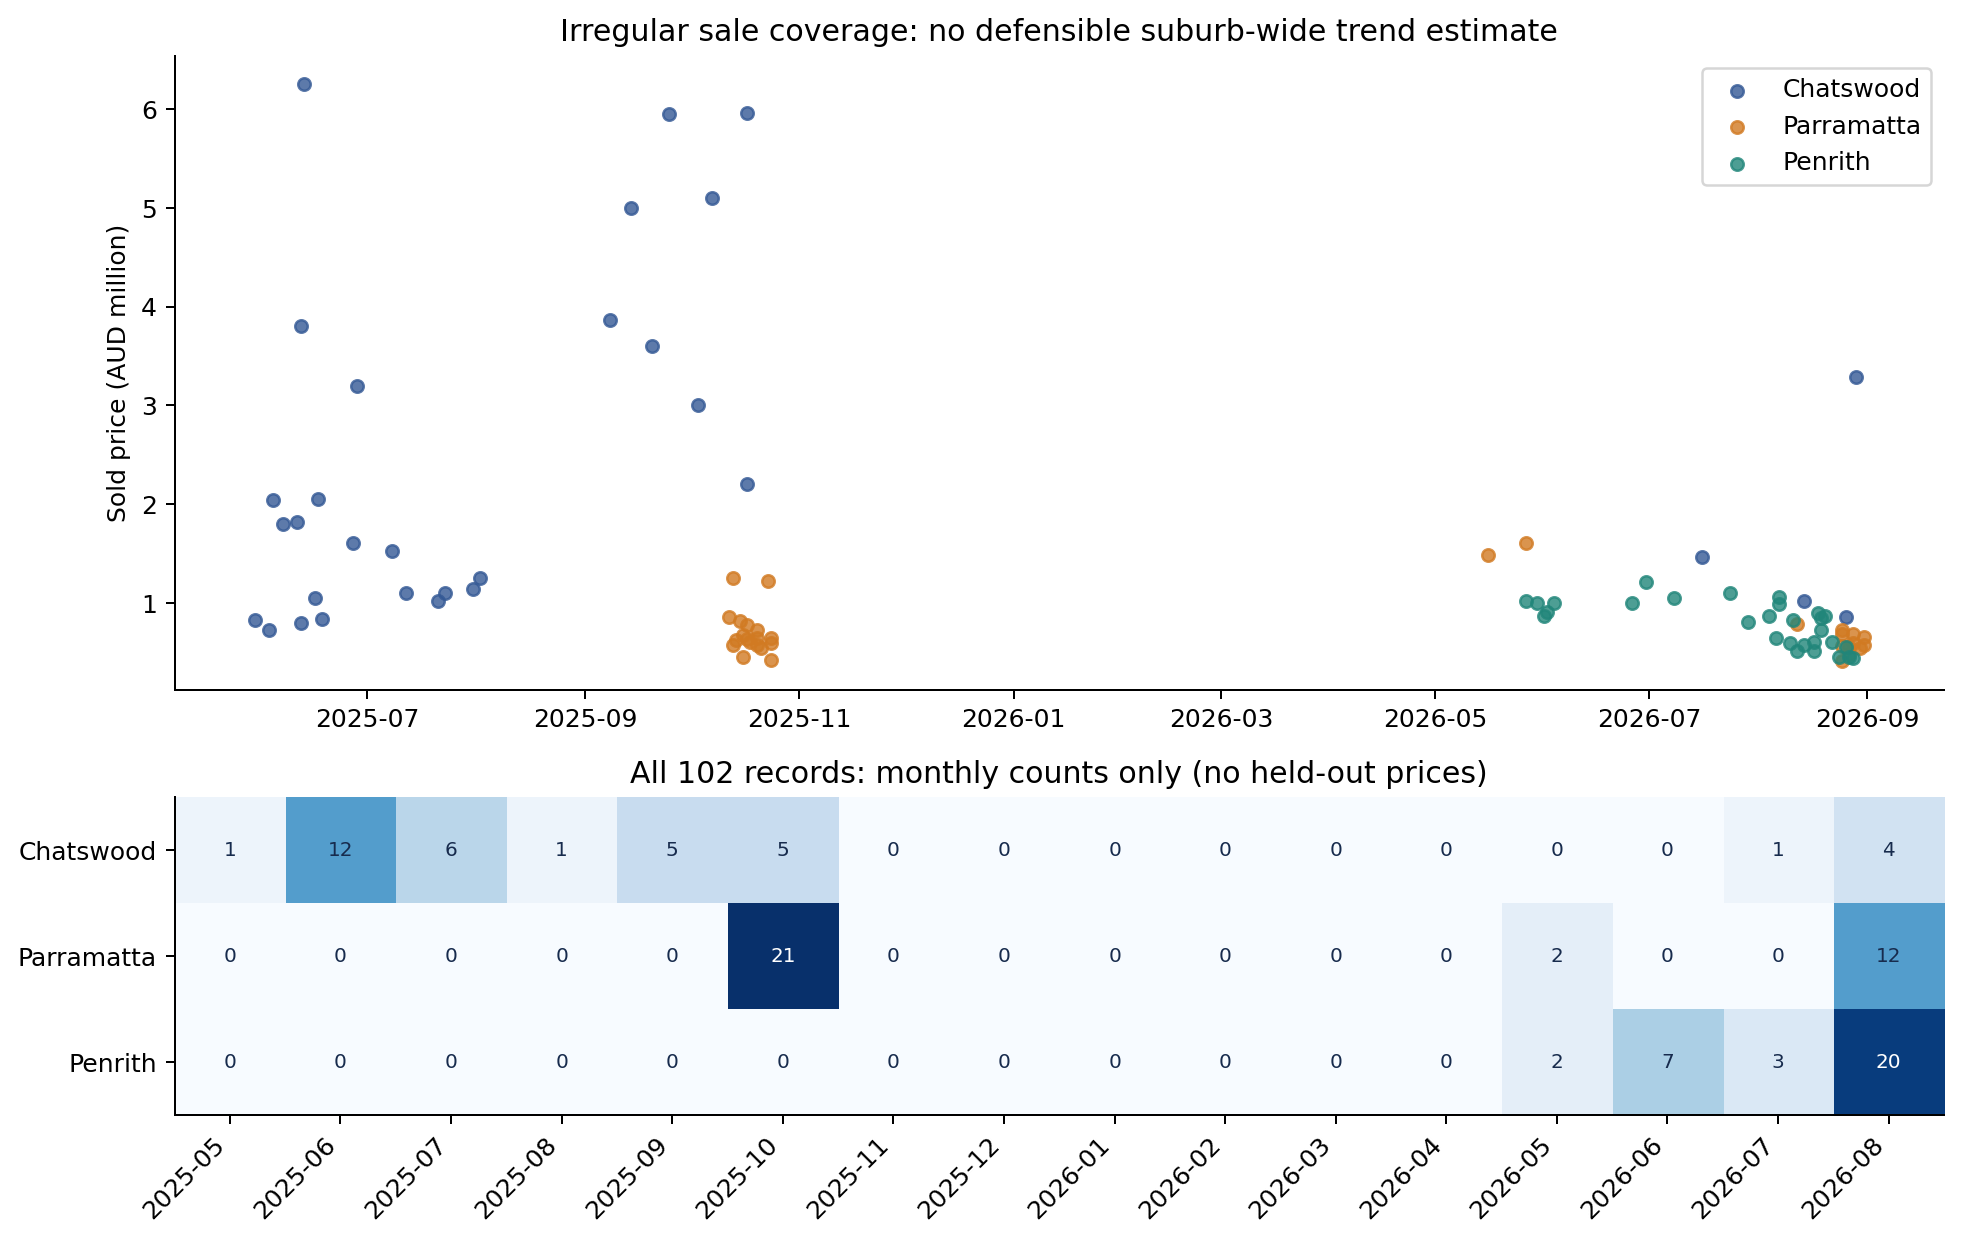

In [100]:
fig,axs=plt.subplots(2,1,figsize=(11,7),gridspec_kw={'height_ratios':[2,1]})
for s in suburbs:
    g=dev[dev.suburb.eq(s)];axs[0].scatter(g.sale_date,g.price_m,c=colors[s],label=s,s=25,alpha=.8)
axs[0].legend();axs[0].set(ylabel='Sold price (AUD million)',title='Irregular sale coverage: no defensible suburb-wide trend estimate')
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
months=pd.period_range(df.sale_date.min(),df.sale_date.max(),freq='M')
coverage=pd.crosstab(df.suburb,df.sale_date.dt.to_period('M')).reindex(index=suburbs,columns=months,fill_value=0)
axs[1].imshow(coverage.values,aspect='auto',cmap='Blues')
axs[1].set(yticks=range(3),yticklabels=suburbs,xticks=range(len(months)),xticklabels=[str(x) for x in months],title='All 102 records: monthly counts only (no held-out prices)')
plt.setp(axs[1].get_xticklabels(),rotation=45,ha='right')
for i in range(3):
    for j in range(len(months)):
        v=int(coverage.iloc[i,j]);axs[1].text(j,i,str(v),ha='center',va='center',color='white' if v>12 else '#172B4D',fontsize=8)
fig.tight_layout();save(fig,'03_time_coverage')

In [101]:
monthly=dev.groupby([dev.sale_date.dt.to_period('M'),'suburb']).sale_price_aud.agg(['count','median']);monthly.to_csv(OUT/'monthly_summary.csv')
coverage.to_csv(OUT/'monthly_counts_all.csv')

display(monthly)

count     median
sale_date suburb                      
2025-05   Chatswood       1   820000.0
2025-06   Chatswood      12  1806500.0
2025-07   Chatswood       5  1100000.0
2025-08   Chatswood       1  1251000.0
2025-09   Chatswood       4  4430000.0
2025-10   Chatswood       4  4050000.0
          Parramatta     18   637500.0
2026-05   Parramatta      2  1545000.0
          Penrith         2  1010000.0
2026-06   Penrith         5  1000000.0
2026-07   Chatswood       1  1460000.0
          Penrith         3  1050000.0
2026-08   Chatswood       3  1016500.0
          Parramatta     12   579500.0
          Penrith        19   600000.0

**Interpretation.** There are no collected sales from November 2025 through April 2026. Suburb, date and dwelling type are confounded. Penrith’s development median changes from AUD 1,000,000 in June 2026 (n=5) to AUD 600,000 in August (n=19), but earlier observations are houses while August includes many apartments. This does not establish a 40% market decline. The chart therefore shows points and coverage instead of a continuous fitted market trend.

## 5. Missingness and the bedroom hypothesis

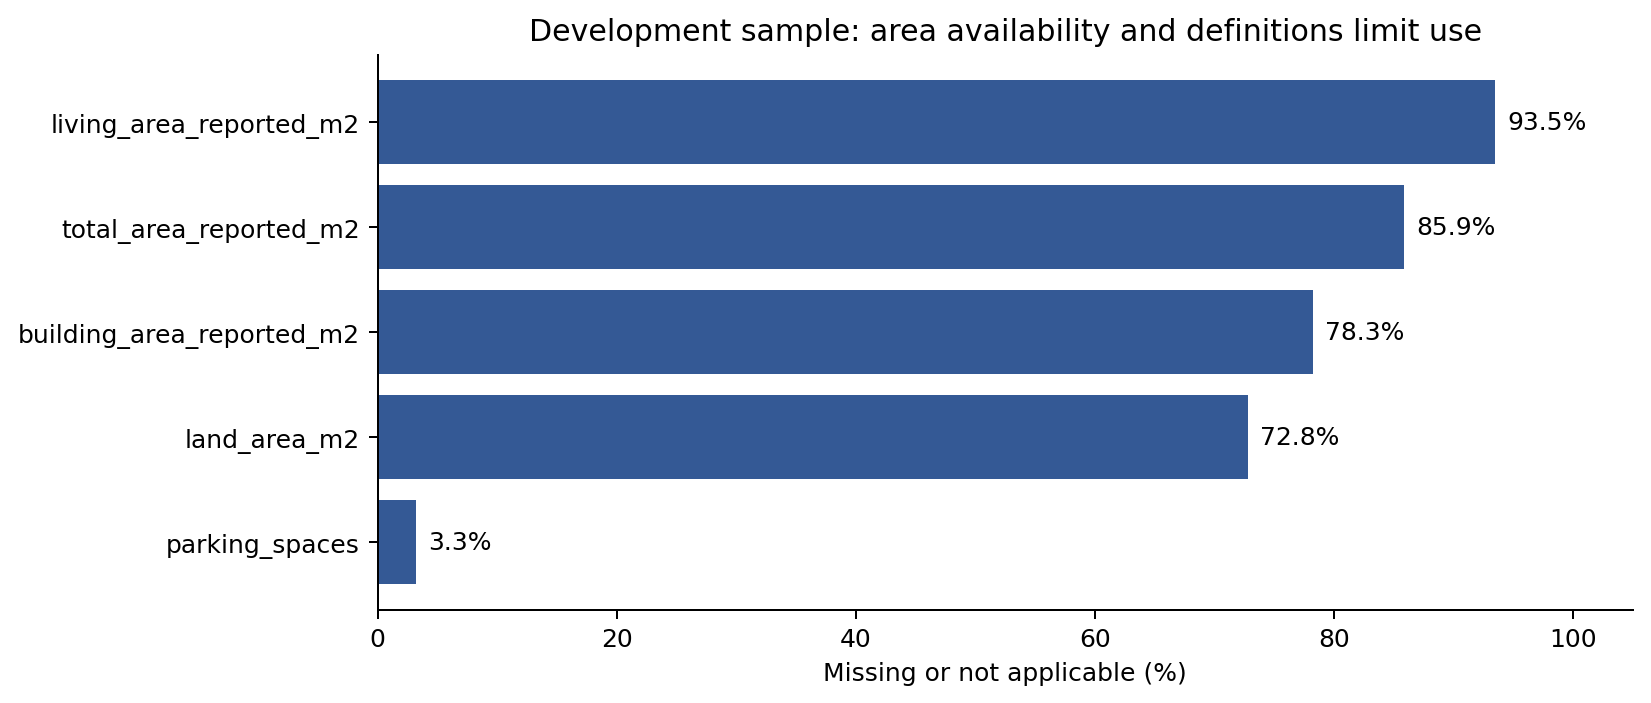

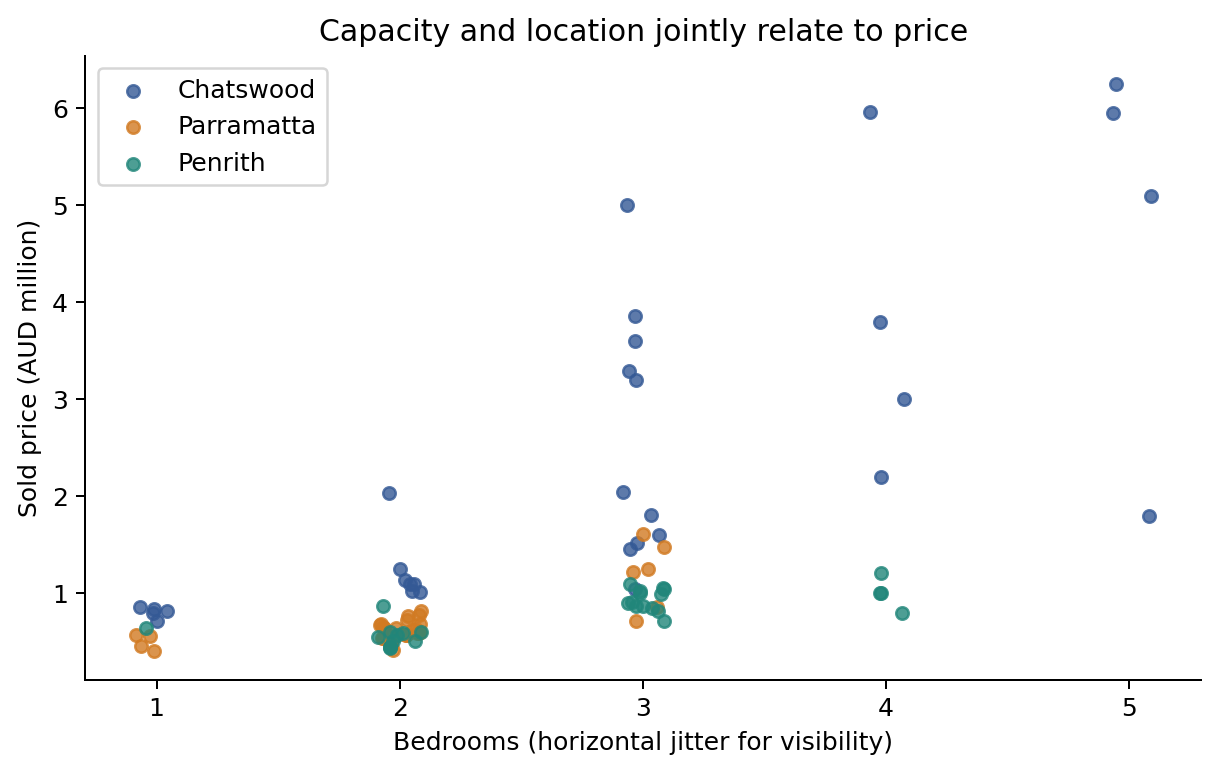

In [102]:
area=['parking_spaces','land_area_m2','building_area_reported_m2','living_area_reported_m2','total_area_reported_m2']
missing=(dev[area].isna().mean()*100).sort_values()
fig,ax=plt.subplots(figsize=(9,4));ax.barh(missing.index,missing.values,color='#345995');ax.set(xlim=(0,105),xlabel='Missing or not applicable (%)',title='Development sample: area availability and definitions limit use')
for i,v in enumerate(missing):ax.text(v+1,i,f'{v:.1f}%',va='center')
save(fig,'04_missingness')
fig,ax=plt.subplots(figsize=(8,4.5))
for s in suburbs:
    g=dev[dev.suburb.eq(s)];ax.scatter(g.bedrooms+rng.uniform(-.09,.09,len(g)),g.price_m,c=colors[s],label=s,s=25,alpha=.8)
ax.set(xlabel='Bedrooms (horizontal jitter for visibility)',ylabel='Sold price (AUD million)',title='Capacity and location jointly relate to price');ax.legend();save(fig,'05_bedrooms')

Missing area can mean unavailable, ambiguous or structurally inapplicable. Land, living area and title area are not interchangeable. The bedroom plot broadly supports the capacity hypothesis, but the pattern also depends on suburb and dwelling type.

## 6. Potential outliers and source-quality problems

In [103]:
q1,q3=dev.sale_price_aud.quantile([.25,.75]);low=q1-1.5*(q3-q1);high=q3+1.5*(q3-q1)
dev['global_iqr_flag']=(dev.sale_price_aud.lt(low)|dev.sale_price_aud.gt(high))
dev['within_suburb_iqr_flag']=False
for s,g in dev.groupby('suburb'):
    a,b=g.sale_price_aud.quantile([.25,.75]);dev.loc[g.index,'within_suburb_iqr_flag']=g.sale_price_aud.lt(a-1.5*(b-a))|g.sale_price_aud.gt(b+1.5*(b-a))
outliers=dev.loc[dev.global_iqr_flag|dev.within_suburb_iqr_flag,['property_id','address','suburb','property_type','sale_price_aud','bedrooms','land_area_m2','global_iqr_flag','within_suburb_iqr_flag','property_notes','source_url']]
outliers.to_csv(OUT/'price_outliers.csv',index=False)
dev.loc[dev.quality_flags.notna(),['property_id','address','quality_flags','area_notes','property_notes','source_url']].to_csv(OUT/'source_quality_issues.csv',index=False)

display(outliers)
print('Global IQR limits (AUD):', low, high)
print('Global flags:', int(dev.global_iqr_flag.sum()))
print('Within-suburb flags:', int(dev.within_suburb_iqr_flag.sum()))
display(dev.loc[dev.quality_flags.notna(), ['property_id','address','quality_flags','area_notes']])

,property_id,address,suburb,property_type,sale_price_aud,bedrooms,land_area_m2,global_iqr_flag,within_suburb_iqr_flag,property_notes,source_url
0,CHA001,14 Jacques Street,Chatswood,House,3290000,3,505.0,True,False,Existing residence advertised with redevelopme...,https://www.realestate.com.au/sold/property-ho...
12,CHA013,28A Greville Street,Chatswood,House,3200000,3,1014.0,True,False,Built in 2022; 7.7 kW solar; double glazing.,https://www.realestate.com.au/sold/property-ho...
17,CHA018,54 Stanley Street,Chatswood,House,6250000,5,NaN,True,False,Built in 2018; ensuite bedrooms; ducted air co...,https://www.realestate.com.au/sold/property-ho...
18,CHA019,25 Dalrymple Avenue,Chatswood,House,3800000,4,701.9,True,False,Pool; self-contained lower level.,https://www.realestate.com.au/sold/property-ho...
25,CHA026,9 Archer Street,Chatswood,House,5960000,4,923.2,True,False,Circa 1890 double-brick home; extension; pool;...,https://www.realestate.com.au/sold/property-ho...
26,CHA027,14 River Avenue,Chatswood,House,2200000,4,591.0,True,False,Updated home; bushland setting; air conditioni...,https://www.realestate.com.au/sold/property-ho...
28,CHA029,2 Blakesley Street,Chatswood,House,5100000,5,556.0,True,False,Four-bedroom main home plus one-bedroom granny...,https://www.realestate.com.au/sold/property-ho...
29,CHA030,15G Colwell Crescent,Chatswood,House,3000000,4,824.0,True,False,Pool; air conditioning; lower level with separ...,https://www.realestate.com.au/sold/property-ho...
30,CHA031,3 Holland Street,Chatswood,House,5950000,5,1018.0,True,False,Ducted air conditioning; study; multiple livin...,https://www.realestate.com.au/sold/property-ho...
32,CHA033,2 McLean Avenue,Chatswood,House,3600000,3,765.1,True,False,Air conditioning; study; cellar.,https://www.realestate.com.au/sold/property-ho...


Global IQR limits (AUD): -346875.0 2178125.0
Global flags: 12
Within-suburb flags: 4


,property_id,address,quality_flags,area_notes
11,CHA012,4/11 Whitton Road,area_definition,Building size scope unclear; may include outdo...
13,CHA014,304/31 Bertram Street,area_definition,Land-labelled 140 is title area; building size...
14,CHA015,8/1 Katherine Street,area_conflict,100 appears as land/layout/balcony in conflict...
15,CHA016,38A Victoria Avenue,type_conflict;bathroom_definition,Individual land area explicitly reported.
18,CHA019,25 Dalrymple Avenue,multi_living_layout,Individual land area explicitly reported.
24,CHA025,101/1 Katherine Street,area_definition,Total 96 includes 18 garage; living area 78 as...
25,CHA026,9 Archer Street,flexible_bedroom,Individual land area explicitly reported.
28,CHA029,2 Blakesley Street,area_rounding;multi_dwelling,Header land 556; description 556.4.
29,CHA030,15G Colwell Crescent,multi_living_layout,Individual land area explicitly reported.
33,CHA034,39 Clanwilliam Street,parking_conflict,Individual land area explicitly reported.


The pooled upper IQR boundary is AUD 2,178,125, flagging 12 Chatswood houses. Within-suburb rules instead flag four Parramatta houses/townhouses. These are contextual flags, not proof of errors; none is automatically deleted. Examples include 54 Stanley Street (AUD 6.25m; five bedrooms/five bathrooms), 9 Archer Street (AUD 5.96m; 923.2 m² land) and 39 Clanwilliam Street (AUD 5m; advertised redevelopment potential).

Measurement problems are separate: retain the suspicious 956.9 m² building value at 16 Bel-air Road in raw data, but do not promote it to a clean floor-area feature. Conflicting title/building measurements at 3/23 Good Street also require conservative treatment.

## 7. Construct candidate features
The three-variable expectations were recorded above before these transformations. All operations below are deterministic and label-independent. Imputation, scaling and fitted text/categorical processing are deferred to training folds in Part 3.

In [104]:
# Deterministic transformations. No imputation, scaling, target encoding or fitted NLP.
df['property_type_group']=df.property_type.replace({'Unit':'Apartment'})
df['sale_month_index']=(df.sale_date.dt.year-2025)*12+df.sale_date.dt.month-1
df['parking_missing']=df.parking_spaces.isna().astype(int)
df['bathrooms_per_bedroom']=df.bathrooms/df.bedrooms.where(df.bedrooms.gt(0))
df['land_area_clean_m2']=df.land_area_m2.where(df.property_type_group.eq('House'))
df['log1p_land_area']=np.log1p(df.land_area_clean_m2)
df['land_area_missing']=df.land_area_clean_m2.isna().astype(int)
# Living and total/title areas remain distinct. Building/unclassified areas are not promoted to clean floor area.
df['living_area_missing']=df.living_area_reported_m2.isna().astype(int)
df['total_area_missing']=df.total_area_reported_m2.isna().astype(int)
notes=df.property_notes.fillna('').str.lower()
df['aircon_mentioned']=notes.str.contains('air conditioning|air conditioners',regex=True).astype(int)
df['study_mentioned']=notes.str.contains('study|office',regex=True).astype(int)
df['outdoor_mentioned']=notes.str.contains('balcony|balconies|courtyard|terrace|backyard|garden|yard|deck',regex=True).astype(int)
df['pool_mentioned']=notes.str.contains('pool').astype(int)
df['pool_nonoperating_mentioned']=notes.str.contains('pool explicitly not operating').astype(int)
df['renovation_mentioned']=notes.str.contains('renovated|renovation|updated|fresh paint|freshly painted|new paint|new carpet',regex=True).astype(int)
# This last mention also captures renovation opportunities; it is not a condition score.

# Feature decisions

These decisions follow the prior expectations in `part2_prior_expectations.md`. `sydney_housing_dataset.csv` contains the collected fields, fixed split and deterministic candidate features in one flat table. It is not a fully imputed training matrix. `property_id` is for joins, `split` for evaluation control, and `sale_price_aud` is the target; none is an input predictor.

1. **`suburb`**  
   **Definition:** Original three-category location.  
   **Rationale and limits:** One of the three expected strongest variables. One-hot encode within the eventual pipeline; do not order suburbs numerically.

2. **`property_type_group`**  
   **Definition:** Unit mapped to Apartment; House/Townhouse retained.  
   **Rationale and limits:** Reduces terminology fragmentation. Source type conflicts remain documented; mapping does not resolve them.

3. **`bedrooms`, `bathrooms`, `parking_spaces`**  
   **Definition:** Original advertised counts.  
   **Rationale and limits:** Bedroom count is the capacity hypothesis. Blank parking remains unknown.

4. **`sale_month_index`**  
   **Definition:** Months since January 2025.  
   **Rationale and limits:** Captures timing without using sale prices. Sparse, confounded coverage limits extrapolation. Use a comparable valuation month in the future app, not an unknown future sale date.

5. **`parking_missing`**  
   **Definition:** 1 when parking count is absent.  
   **Rationale and limits:** Preserves disclosure information; may encode advertiser behaviour rather than value.

6. **`bathrooms_per_bedroom`**  
   **Definition:** Bathrooms divided by positive bedroom count.  
   **Rationale and limits:** Tests amenity provision relative to capacity. Correlated with component counts; keep only if later validation supports it.

7. **`land_area_clean_m2`**  
   **Definition:** Reported individual land only for source-classified houses.  
   **Rationale and limits:** Excludes strata title/whole-building land. Rounded source measurements remain approximate.

8. **`log1p_land_area`**  
   **Definition:** Natural log of (1 + land area).  
   **Rationale and limits:** Candidate diminishing-return transformation. Compare against original area rather than automatically using both.

9. **`land_area_missing`**  
   **Definition:** Clean land area unavailable.  
   **Rationale and limits:** For apartments often structurally inapplicable, not merely unreported.

10. **`living_area_reported_m2`, `total_area_reported_m2`**  
    **Definition:** Separately retained definitions.  
    **Rationale and limits:** Sparse experimental features; living may include balcony and title includes non-living areas. Do not combine into a general floor-area column.

11. **`living_area_missing`, `total_area_missing`**  
    **Definition:** Respective unavailable indicators.  
    **Rationale and limits:** Retain only with the corresponding candidate area features.

12. **`aircon_mentioned`, `study_mentioned`, `outdoor_mentioned`**  
    **Definition:** Keyword mentions in paraphrased notes.  
    **Rationale and limits:** Optional, weak text proxies. A zero means no captured mention, not absence. Study may be a bedroom alternative.

13. **`pool_mentioned`, `pool_nonoperating_mentioned`**  
    **Definition:** Any pool mention and explicit non-operation.  
    **Rationale and limits:** Shared pools differ from private pools. Non-operation must not be mistaken for an amenity of equal value.

14. **`renovation_mentioned`**  
    **Definition:** Renovation/update language including renovation opportunities.  
    **Rationale and limits:** Measures discussion of condition, NOT good condition. Requires improved manual coding before use as a quality signal.




In [105]:
# Refresh the development view with the candidate features, preserving EDA flags.
eda_flags=dev[['property_id','global_iqr_flag','within_suburb_iqr_flag']]
dev=df[df.split.eq('development')].copy().merge(eda_flags,on='property_id',validate='one_to_one')
numeric=['bedrooms','bathrooms','parking_spaces','land_area_clean_m2','living_area_reported_m2','total_area_reported_m2']
corr=[{'variable':x,'paired_n':int(dev[[x,'sale_price_aud']].dropna().shape[0]),'spearman':dev[x].corr(dev.sale_price_aud,method='spearman')} for x in numeric]
pd.DataFrame(corr).to_csv(OUT/'numeric_associations.csv',index=False)

display(pd.DataFrame(corr))

,variable,paired_n,spearman
0,bedrooms,92,0.710214
1,bathrooms,92,0.276047
2,parking_spaces,89,0.659555
3,land_area_clean_m2,25,0.280793
4,living_area_reported_m2,6,0.579771
5,total_area_reported_m2,13,0.505495


**Reflection.** Bedrooms show a positive pooled Spearman association (0.71, n=92); parking also correlates positively (0.66, n=89). These unadjusted correlations do not establish causal effects or fitted importance. Land has only 25 complete pairs and living area only six. Location/type patterns and the bedroom association broadly align with expectations, while measurement limitations justify caution about area and promotional text. Later validation should compare a small baseline with optional area/text features rather than automatically including every candidate.

## 8. Export and validate


In [106]:
features=['suburb','property_type_group','bedrooms','bathrooms','parking_spaces','sale_month_index','parking_missing','bathrooms_per_bedroom','land_area_clean_m2','log1p_land_area','land_area_missing','living_area_reported_m2','living_area_missing','total_area_reported_m2','total_area_missing','aircon_mentioned','study_mentioned','outdoor_mentioned','pool_mentioned','pool_nonoperating_mentioned','renovation_mentioned']
assert len(df)==102 and len(dev)==92 and df.split.eq('heldout').sum()==10
assert DATA_FILE.name == 'sydney_housing_dataset.csv'
assert not df[features].select_dtypes('number').isin([np.inf,-np.inf]).any().any()
results={'development_n':len(dev),'heldout_n':10,'median':float(dev.sale_price_aud.median()),'mean':float(dev.sale_price_aud.mean()),'skewness':float(dev.sale_price_aud.skew()),'iqr_lower':float(low),'iqr_upper':float(high),'global_outliers':int(dev.global_iqr_flag.sum()),'within_suburb_outliers':int(dev.within_suburb_iqr_flag.sum()),'outlier_ids':outliers.property_id.tolist(),'numeric_associations':corr,'missing':dev[area].isna().sum().to_dict()}
(OUT/'eda_summary.json').write_text(json.dumps(results,indent=2))
display(pd.DataFrame([results]).drop(columns=['numeric_associations','outlier_ids','missing']))


,development_n,heldout_n,median,mean,skewness,iqr_lower,iqr_upper,global_outliers,within_suburb_outliers
0,92,10,852500.0,1.315885e+06,2.47558,-346875.0,2178125.0,12,4


## Part 3 — Model Development and Evaluation

### Model choices and expectations recorded before training

Three regressors represent distinct levels of flexibility:

1. **Ridge regression** is the interpretable regularised linear baseline. It should be stable on 92 development records, but may underfit nonlinear interactions among suburb, type, land and rooms.
2. **Random forest regression** averages many decision trees. It can learn nonlinear thresholds and interactions without distributional assumptions, but can overfit a small sample and cannot extrapolate beyond observed price patterns.
3. **Decision tree regression** divides the data into simple decision rules, such as suburb, dwelling type and room thresholds. It is easy to explain and can represent nonlinear relationships, but a single tree may be unstable and overfit this small dataset. I expect random forest to perform best because averaging many trees should reduce that instability.

These expectations precede all code and results below. Hyperparameters are fixed rather than tuned through a large search. Five-fold shuffled cross-validation uses the same folds for every model. MAE is the primary selection metric because it is directly interpretable in AUD and less dominated by luxury properties than RMSE. RMSE, R², and train–validation gaps provide additional evidence.

In [107]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MODEL_OUT = ROOT / 'outputs/final'
MODEL_OUT.mkdir(parents=True, exist_ok=True)
categorical_features = ['suburb', 'property_type_group']
numeric_features = ['bedrooms', 'bathrooms', 'parking_spaces', 'sale_month_index',
                    'land_area_clean_m2', 'aircon_mentioned', 'study_mentioned',
                    'outdoor_mentioned', 'pool_mentioned', 'renovation_mentioned']
model_features = categorical_features + numeric_features

development = df[df['split'].eq('development')].copy()
heldout = df[df['split'].eq('heldout')].copy()
X_dev, y_dev = development[model_features], development['sale_price_aud']

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
scaled_preprocessor = ColumnTransformer([
    ('categorical', categorical_pipe, categorical_features),
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler())
    ]), numeric_features)
])
tree_preprocessor = ColumnTransformer([
    ('categorical', categorical_pipe, categorical_features),
    ('numeric', SimpleImputer(strategy='median', add_indicator=True), numeric_features)
])

models = {
    'Ridge': Pipeline([('preprocess', scaled_preprocessor), ('model', Ridge(alpha=10.0))]),
    'Random forest': Pipeline([('preprocess', tree_preprocessor),
        ('model', RandomForestRegressor(n_estimators=500, max_depth=6, min_samples_leaf=2,
                                        max_features=0.8, random_state=720, n_jobs=-1))]),
    'Decision tree': Pipeline([('preprocess', tree_preprocessor),
        ('model', DecisionTreeRegressor(max_depth=4, min_samples_leaf=3, random_state=720))])
}
cv = KFold(n_splits=5, shuffle=True, random_state=720)
scoring = {'mae':'neg_mean_absolute_error', 'rmse':'neg_root_mean_squared_error', 'r2':'r2'}
cv_rows = []
for name, model in models.items():
    result = cross_validate(model, X_dev, y_dev, cv=cv, scoring=scoring,
                            return_train_score=True, n_jobs=-1)
    cv_rows.append({
        'model': name,
        'CV MAE mean': -result['test_mae'].mean(), 'CV MAE SD': result['test_mae'].std(),
        'CV RMSE mean': -result['test_rmse'].mean(), 'CV RMSE SD': result['test_rmse'].std(),
        'CV R2 mean': result['test_r2'].mean(), 'CV R2 SD': result['test_r2'].std(),
        'Train MAE mean': -result['train_mae'].mean(), 'Train R2 mean': result['train_r2'].mean()
    })
cv_results = pd.DataFrame(cv_rows).sort_values('CV MAE mean').reset_index(drop=True)
display(cv_results.style.format({c:'{:,.0f}' for c in ['CV MAE mean','CV MAE SD','CV RMSE mean','CV RMSE SD','Train MAE mean']}
                                | {c:'{:.3f}' for c in ['CV R2 mean','CV R2 SD','Train R2 mean']}))
cv_results.to_csv(MODEL_OUT/'model_cv_results.csv', index=False)

,model,CV MAE mean,CV MAE SD,CV RMSE mean,CV RMSE SD,CV R2 mean,CV R2 SD,Train MAE mean,Train R2 mean
0,Random forest,"365,548","110,227","725,218","239,109",0.560,0.164,"209,600",0.892
1,Decision tree,"472,149","207,329","933,511","436,104",0.406,0.305,"265,547",0.834
2,Ridge,"477,130","102,624","709,952","141,717",0.366,0.631,"402,462",0.800


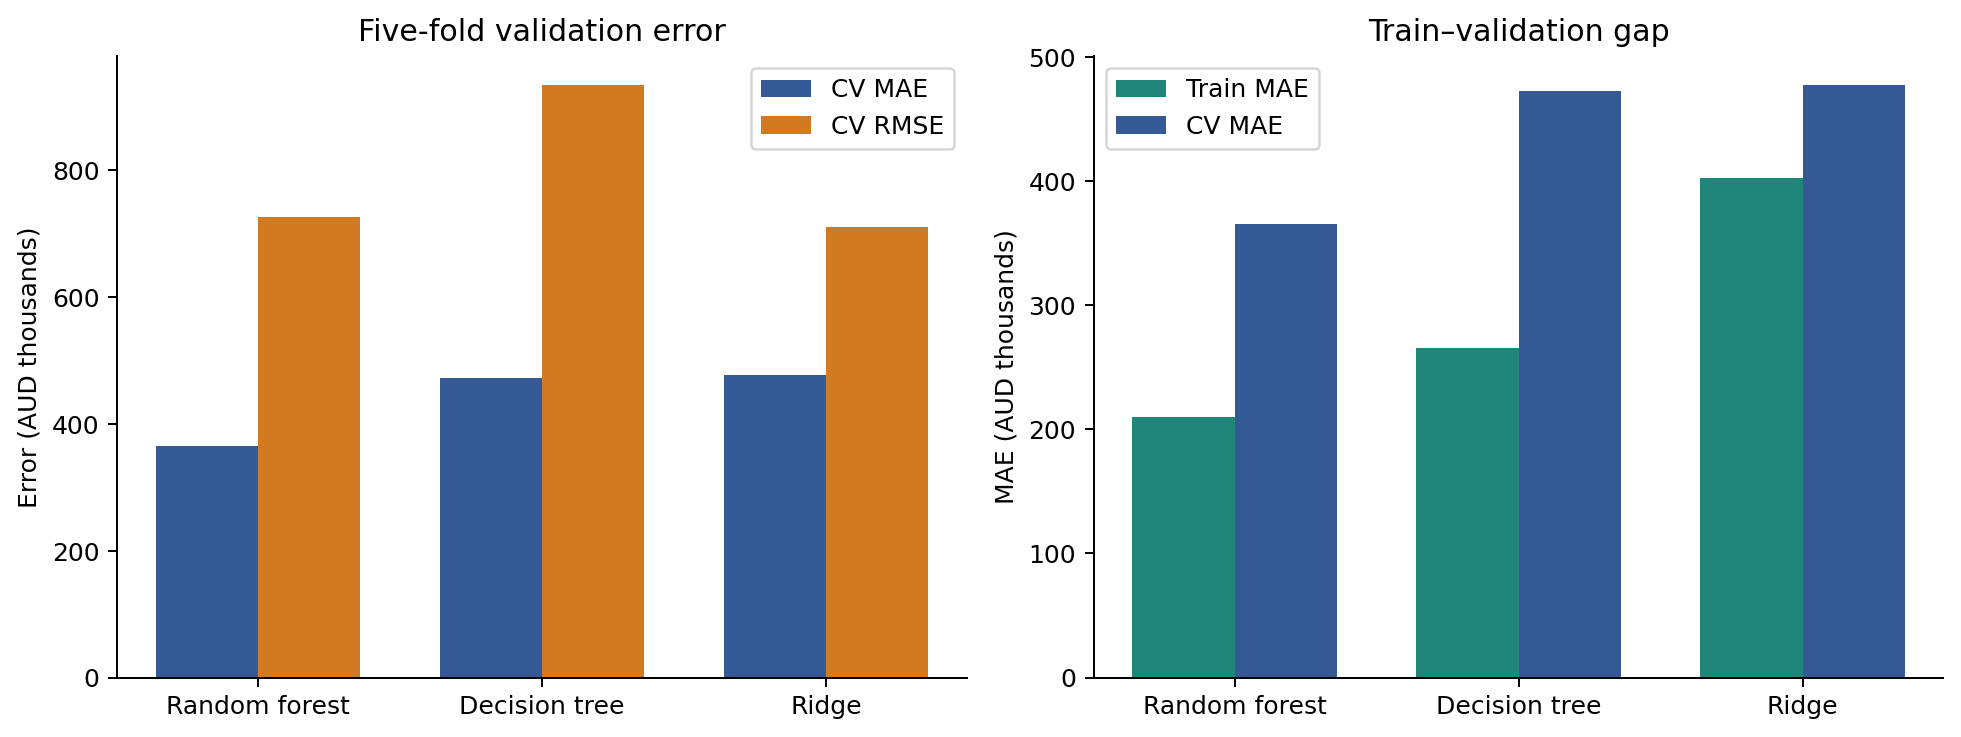

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(cv_results))
axes[0].bar(x-0.18, cv_results['CV MAE mean']/1000, width=.36, label='CV MAE', color='#345995')
axes[0].bar(x+0.18, cv_results['CV RMSE mean']/1000, width=.36, label='CV RMSE', color='#D17A22')
axes[0].set(xticks=x, xticklabels=cv_results['model'], ylabel='Error (AUD thousands)',
            title='Five-fold validation error')
axes[0].legend()
axes[1].bar(x-0.18, cv_results['Train MAE mean']/1000, width=.36, label='Train MAE', color='#21867A')
axes[1].bar(x+0.18, cv_results['CV MAE mean']/1000, width=.36, label='CV MAE', color='#345995')
axes[1].set(xticks=x, xticklabels=cv_results['model'], ylabel='MAE (AUD thousands)',
            title='Train–validation gap')
axes[1].legend()
fig.tight_layout()
fig.savefig(MODEL_OUT/'06_model_comparison.png', bbox_inches='tight', dpi=180)
display(Image(filename=str(MODEL_OUT/'06_model_comparison.png'))); plt.close(fig)

### Evaluation and recommendation

Random forest has the lowest mean CV MAE (**AUD 365,548**) and the highest mean CV R² (**0.560**), supporting the original expectation. Decision tree records a CV MAE of **AUD 472,149** and mean CV R² of **0.406**. Ridge has a similar but slightly worse MAE (**AUD 477,130**) and lower mean CV R² (**0.366**), indicating that a single linear relationship underfits the nonlinear differences among location, dwelling type, land and rooms.

The single decision tree reduces training MAE to about **AUD 265,547**, but its validation MAE rises to AUD 472,149. This large gap and its high variation across folds indicate instability and overfitting. Random forest also has a train–validation gap—about **AUD 209,600** versus AUD 365,548—but averaging many trees improves its validation performance. Ridge has the smallest MAE gap, yet its comparatively weak validation results suggest underfitting rather than better generalisation. Random forest is therefore recommended. Its CV RMSE remains high (**AUD 725,218**) because several luxury Chatswood houses generate very large errors. This conclusion applies to this small dataset and does not mean random forest is always the best regression model.


## Part 4 — Investigating Prediction Failures

The five cases below use predictions generated through five-fold cross-validation with the recommended model. In each fold, predictions are made for the validation properties using a model trained on the other four folds. This avoids using optimistic training-set residuals for the failure analysis.

,property_id,address,sale_price_aud,cv_prediction_aud,error_aud,absolute_percentage_error,property_notes
17,CHA018,54 Stanley Street,"$6,250,000","$2,366,524","$-3,883,476",62.1%,Built in 2018; ensuite bedrooms; ducted air conditioning; media room and office.
33,CHA034,39 Clanwilliam Street,"$5,000,000","$1,961,913","$-3,038,087",60.8%,Circa 1920 bungalow; redevelopment potential claimed. Description parking differs from header.
25,CHA026,9 Archer Street,"$5,960,000","$3,218,074","$-2,741,926",46.0%,Circa 1890 double-brick home; extension; pool; air conditioning; flexible office/fifth bedroom.
21,CHA022,96 Millwood Avenue,"$1,800,000","$4,136,155","$2,336,155",129.8%,Three levels; north-facing bush views; study.
34,CHA035,18 Park Avenue,"$3,860,000","$1,960,353","$-1,899,647",49.2%,Original kitchen and bathroom; north aspect; redevelopment potential; advertised 950 m to station.


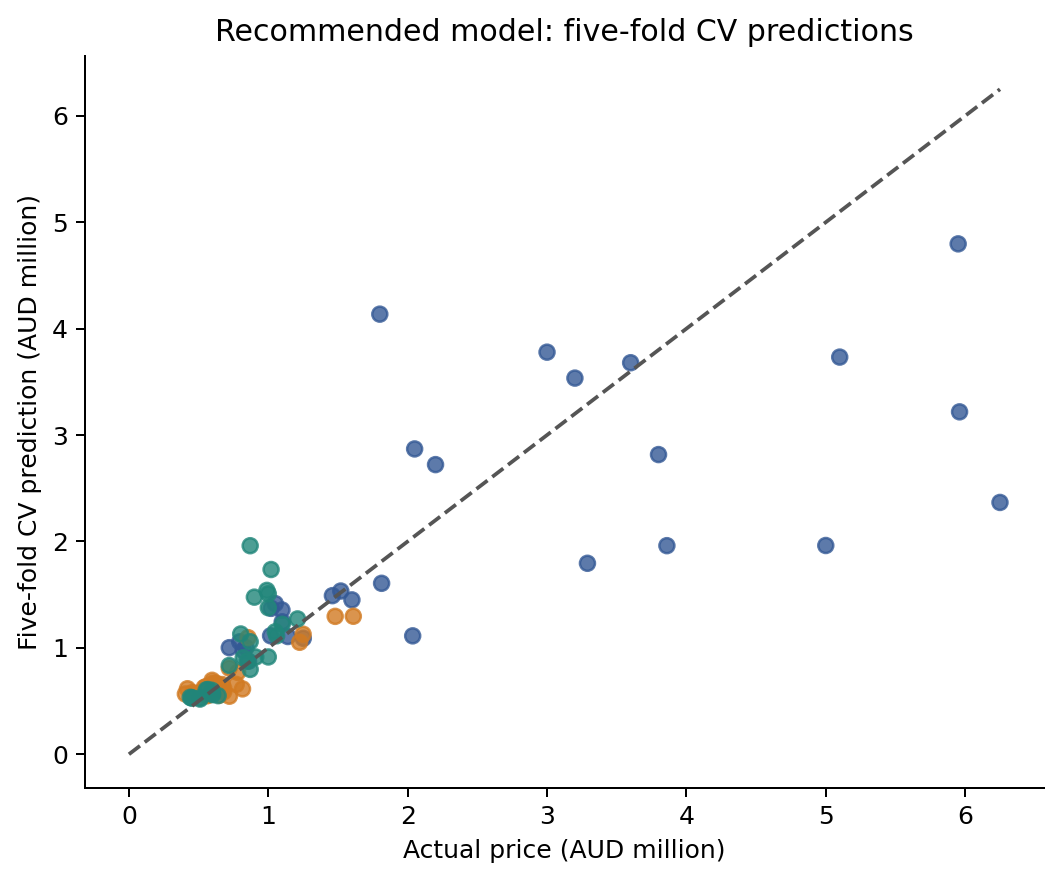

In [109]:
best_model_name = cv_results.iloc[0]['model']
best_model = models[best_model_name]
model_summary = {
    'best_model': best_model_name,
    'selection_metric': 'mean five-fold CV MAE',
    'best_cv_mae': float(cv_results.iloc[0]['CV MAE mean']),
    'best_cv_rmse': float(cv_results.iloc[0]['CV RMSE mean']),
    'best_cv_r2': float(cv_results.iloc[0]['CV R2 mean']),
    'development_n': len(development),
    'heldout_n': len(heldout)
}
(MODEL_OUT/'model_summary.json').write_text(json.dumps(model_summary, indent=2))
cv_prediction = cross_val_predict(best_model, X_dev, y_dev, cv=cv, n_jobs=-1)
failure_analysis = development[['property_id','address','suburb','property_type_group',
    'sale_price_aud','bedrooms','bathrooms','parking_spaces','land_area_clean_m2',
    'property_notes','quality_flags','source_url']].copy()
failure_analysis['cv_prediction_aud'] = cv_prediction
failure_analysis['error_aud'] = failure_analysis['cv_prediction_aud'] - failure_analysis['sale_price_aud']
failure_analysis['absolute_error_aud'] = failure_analysis['error_aud'].abs()
failure_analysis['absolute_percentage_error'] = failure_analysis['absolute_error_aud'] / failure_analysis['sale_price_aud']
worst_five = failure_analysis.nlargest(5, 'absolute_error_aud')
display(worst_five[['property_id','address','sale_price_aud','cv_prediction_aud',
                    'error_aud','absolute_percentage_error','property_notes']]
        .style.format({'sale_price_aud':'${:,.0f}','cv_prediction_aud':'${:,.0f}',
                       'error_aud':'${:,.0f}','absolute_percentage_error':'{:.1%}'}))
worst_five.to_csv(MODEL_OUT/'five_largest_errors.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_dev/1e6, cv_prediction/1e6, c=development['suburb'].map(colors), alpha=.8)
limit=max(y_dev.max(),cv_prediction.max())/1e6
ax.plot([0,limit],[0,limit],'--',color='#555555')
ax.set(xlabel='Actual price (AUD million)', ylabel='Five-fold CV prediction (AUD million)',
       title='Recommended model: five-fold CV predictions')
fig.tight_layout(); fig.savefig(MODEL_OUT/'07_cv_predictions.png',bbox_inches='tight',dpi=180)
display(Image(filename=str(MODEL_OUT/'07_cv_predictions.png'))); plt.close(fig)

### Five largest errors

1. **54 Stanley Street, Chatswood:** the model predicts about AUD 2.37m versus AUD 6.25m. Five bedrooms, five bathrooms, recent construction and premium media/office space do not fully describe architecture, finish quality or exact micro-location. Missing reliable floor area is material.
2. **39 Clanwilliam Street, Chatswood:** prediction is about AUD 1.96m versus AUD 5.00m. The price may reflect land or redevelopment value that room counts cannot capture; the listing also has a parking conflict.
3. **9 Archer Street, Chatswood:** prediction is about AUD 3.22m versus AUD 5.96m. The large 923.2 m² parcel, heritage character, extension and pool create a rare combination with few comparables.
4. **96 Millwood Avenue, Chatswood:** prediction is about AUD 4.14m versus AUD 1.80m. The model overgeneralises from five-bedroom Chatswood houses. Bush setting, condition, access, layout quality or other unrecorded drawbacks may explain the discount.
5. **18 Park Avenue, Chatswood:** prediction is about AUD 1.96m versus AUD 3.86m. The original interior and redevelopment potential point in opposite directions: condition reduces current utility while land potential can raise buyer value.

All five are Chatswood houses. This concentration shows that rare, heterogeneous detached homes are harder than standard apartments. A tree ensemble tends to pull exceptional prices toward patterns learned from more common properties and can also overprice an ordinary large house. Reliable internal area, renovation quality, building age, precise coordinates, planning controls, views, noise, flood exposure, strata/building defects and more local comparable sales could reduce these errors. Predictions require particular caution for luxury, heritage, development-site, dual-living and restricted-occupancy properties, or whenever key areas and condition are missing.


## Part 5 — Machine Learning, LLM and Human Judgement

The ten fixed held-out properties were excluded from model selection. The next table presents the same non-price information for all three valuation approaches. The LLM estimates and the round, intuition-based personal estimates were fixed before the comparison cell revealed actual prices. However, the broader project session had already handled the source dataset, so the LLM result is **not a strong independent blind benchmark**.


In [110]:
final_model = best_model.fit(X_dev, y_dev)
heldout_inputs = heldout[['property_id','address','suburb','property_type_group','bedrooms',
    'bathrooms','parking_spaces','land_area_clean_m2','sale_date','property_notes']].copy()
heldout_inputs['ml_prediction_aud'] = final_model.predict(heldout[model_features])
display(heldout_inputs.style.format({'land_area_clean_m2':'{:,.1f}','ml_prediction_aud':'${:,.0f}'}))

# Estimates produced from the displayed non-price fields. Do not alter after viewing actual prices.
llm_estimates = {
    'CHA004':1550000, 'CHA008':1250000, 'CHA028':3600000, 'CHA032':3700000,
    'PAR007':750000, 'PAR018':680000, 'PAR019':780000,
    'PEN012':900000, 'PEN013':1120000, 'PEN019':520000
}

# Personal estimates recorded as round, intuition-based judgements before viewing actual prices.
student_estimates = {
    'CHA004':1600000, 'CHA008':1350000, 'CHA028':3400000, 'CHA032':3800000,
    'PAR007':720000, 'PAR018':700000, 'PAR019':820000,
    'PEN012':850000, 'PEN013':1050000, 'PEN019':550000
}


,property_id,address,suburb,property_type_group,bedrooms,bathrooms,parking_spaces,land_area_clean_m2,sale_date,property_notes,ml_prediction_aud
3,CHA004,1205/1 Cambridge Lane,Chatswood,Apartment,2,2,1.000000,nan,2026-08-11 00:00:00,Corner apartment; premium finishes described.,"$1,207,046"
7,CHA008,3/7 Freeman Road,Chatswood,Apartment,2,2,1.000000,nan,2025-07-23 00:00:00,Large terrace; air conditioning.,"$1,266,095"
27,CHA028,102 Millwood Avenue,Chatswood,House,5,3,3.000000,963.0,2025-10-09 00:00:00,Full brick; renovated; elevated bush views.,"$4,570,240"
31,CHA032,40 Beaconsfield Road,Chatswood,House,5,3,4.000000,613.0,2025-09-20 00:00:00,Pool; ducted air conditioning; study.,"$4,646,987"
41,PAR007,44/23 Good Street,Parramatta,Apartment,2,2,2.000000,nan,2025-10-23 00:00:00,Level 7; park views.,"$729,723"
52,PAR018,6813/1A Morton Street,Parramatta,Apartment,2,2,1.000000,nan,2025-10-15 00:00:00,Level 8; study; communal gym.,"$659,628"
53,PAR019,1106/12 Phillip Street,Parramatta,Apartment,2,2,1.000000,nan,2025-10-14 00:00:00,Level 11; north river and stadium views; pool and gym; air conditioning; study.,"$661,841"
80,PEN012,38 Brown Street,Penrith,House,3,1,2.000000,588.0,2026-06-19 00:00:00,Original home; renovation opportunity; workshop.,"$1,047,549"
81,PEN013,28 Rawson Avenue,Penrith,House,4,2,2.000000,498.0,2026-06-15 00:00:00,Solar; air conditioning; multiple living areas.,"$1,233,136"
87,PEN019,25/132 Lethbridge Street,Penrith,Apartment,2,1,1.000000,nan,2026-08-28 00:00:00,Renovated; communal pool; balcony; garage.,"$532,629"


,property_id,address,suburb,sale_price_aud,ML estimate,LLM estimate,Student estimate,ML estimate absolute error,LLM estimate absolute error,Student estimate absolute error
3,CHA004,1205/1 Cambridge Lane,Chatswood,"$1,951,000","$1,207,046","$1,550,000","$1,600,000","$743,954","$401,000","$351,000"
7,CHA008,3/7 Freeman Road,Chatswood,"$1,180,000","$1,266,095","$1,250,000","$1,350,000","$86,095","$70,000","$170,000"
27,CHA028,102 Millwood Avenue,Chatswood,"$2,088,000","$4,570,240","$3,600,000","$3,400,000","$2,482,240","$1,512,000","$1,312,000"
31,CHA032,40 Beaconsfield Road,Chatswood,"$3,650,000","$4,646,987","$3,700,000","$3,800,000","$996,987","$50,000","$150,000"
41,PAR007,44/23 Good Street,Parramatta,"$745,000","$729,723","$750,000","$720,000","$15,277","$5,000","$25,000"
52,PAR018,6813/1A Morton Street,Parramatta,"$650,000","$659,628","$680,000","$700,000","$9,628","$30,000","$50,000"
53,PAR019,1106/12 Phillip Street,Parramatta,"$790,000","$661,841","$780,000","$820,000","$128,159","$10,000","$30,000"
80,PEN012,38 Brown Street,Penrith,"$1,025,000","$1,047,549","$900,000","$850,000","$22,549","$125,000","$175,000"
81,PEN013,28 Rawson Avenue,Penrith,"$1,215,000","$1,233,136","$1,120,000","$1,050,000","$18,136","$95,000","$165,000"
87,PEN019,25/132 Lethbridge Street,Penrith,"$460,000","$532,629","$520,000","$550,000","$72,629","$60,000","$90,000"


,approach,n,MAE,RMSE,R2
0,ML,10,"$457,565","$879,730",0.068
1,LLM,10,"$235,800","$498,359",0.701
2,Student,10,"$251,800","$443,387",0.763


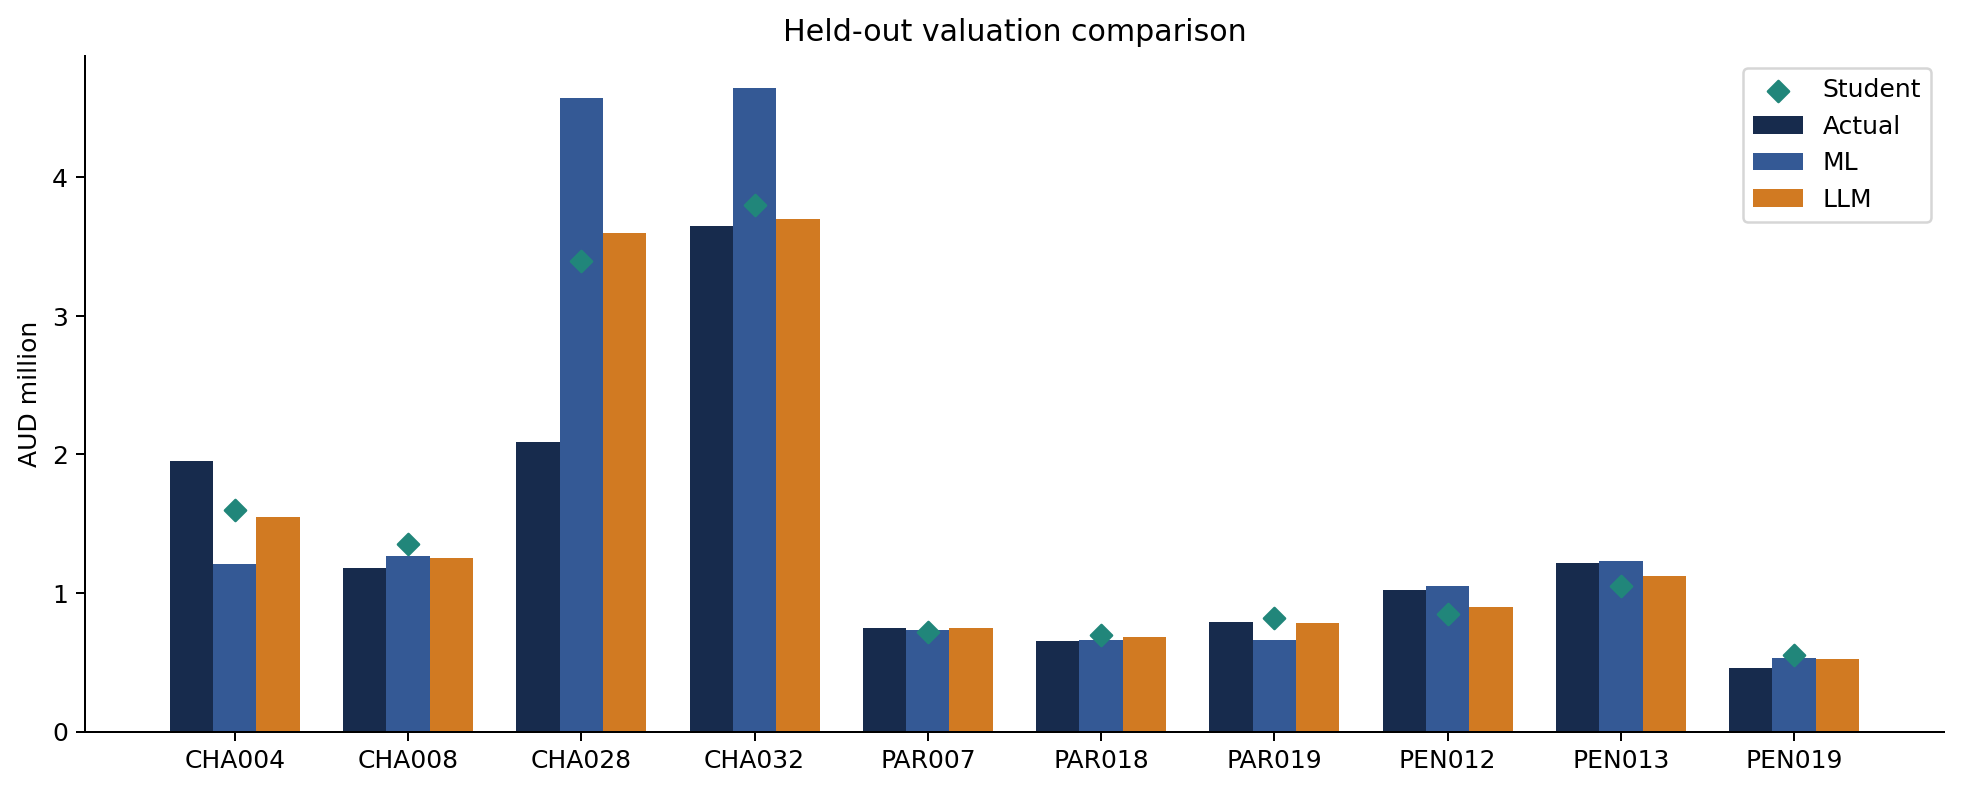

In [111]:
comparison = heldout[['property_id','address','suburb','sale_price_aud']].copy()
comparison['ML estimate'] = final_model.predict(heldout[model_features])
comparison['LLM estimate'] = comparison['property_id'].map(llm_estimates)
comparison['Student estimate'] = comparison['property_id'].map(student_estimates)
for column in ['ML estimate','LLM estimate','Student estimate']:
    comparison[column+' absolute error'] = (comparison[column]-comparison['sale_price_aud']).abs()

student_complete = comparison['Student estimate'].notna().all()
if student_complete:
    metric_rows=[]
    for label in ['ML estimate','LLM estimate','Student estimate']:
        actual=comparison['sale_price_aud']; pred=comparison[label]
        metric_rows.append({'approach':label.replace(' estimate',''),'n':len(comparison),
            'MAE':mean_absolute_error(actual,pred),
            'RMSE':mean_squared_error(actual,pred)**0.5,
            'R2':r2_score(actual,pred)})
    comparison_metrics=pd.DataFrame(metric_rows)
    display(comparison.style.format({c:'${:,.0f}' for c in comparison.columns if 'estimate' in c or 'error' in c}
                                    | {'sale_price_aud':'${:,.0f}'}))
    display(comparison_metrics.style.format({'MAE':'${:,.0f}','RMSE':'${:,.0f}','R2':'{:.3f}'}))
    comparison.to_csv(MODEL_OUT/'heldout_three_way_comparison.csv', index=False)
else:
    display(comparison.drop(columns=['sale_price_aud'] + [c for c in comparison if c.endswith('absolute error')])
            .style.format({'ML estimate':'${:,.0f}','LLM estimate':'${:,.0f}','Student estimate':'${:,.0f}'}))
    print('Actual prices and comparative metrics are hidden until all ten student estimates are entered.')

if student_complete:
    fig, ax=plt.subplots(figsize=(11,4.5)); positions=np.arange(len(comparison)); width=.25
    ax.bar(positions-width,comparison['sale_price_aud']/1e6,width,label='Actual',color='#172B4D')
    ax.bar(positions,comparison['ML estimate']/1e6,width,label='ML',color='#345995')
    ax.bar(positions+width,comparison['LLM estimate']/1e6,width,label='LLM',color='#D17A22')
    if comparison['Student estimate'].notna().all():
        ax.scatter(positions,comparison['Student estimate']/1e6,label='Student',color='#21867A',marker='D')
    ax.set(xticks=positions,xticklabels=comparison['property_id'],ylabel='AUD million',
           title='Held-out valuation comparison');ax.legend();fig.tight_layout()
    fig.savefig(MODEL_OUT/'08_heldout_comparison.png',bbox_inches='tight',dpi=180)
    display(Image(filename=str(MODEL_OUT/'08_heldout_comparison.png')));plt.close(fig)
else:
    print('Comparison chart will be created after the student estimates are complete.')

### Comparison interpretation

Using MAE as the main measure, the LLM performs best on the ten held-out properties with an MAE of **AUD 235,800**. The intuition-based student estimates are close at **AUD 251,800**, while the machine-learning model has the largest MAE at **AUD 457,565**. The ranking changes for other metrics: the student estimates have the lowest RMSE (**AUD 443,387**) and highest R² (**0.763**), followed by the LLM with RMSE **AUD 498,359** and R² **0.701**. The ML model records RMSE **AUD 879,730** and R² **0.068**.

The LLM produces the smallest absolute error for five properties, the ML model for three and the student estimates for two. The ML model performs well on several more typical Parramatta and Penrith properties, but its large overestimates for CHA028 and CHA032 dominate its overall error. This matches the earlier failure analysis: unusual Chatswood properties are difficult to estimate from the limited structured features and small sample.

The LLM gives more balanced estimates across this test set and is especially close for CHA032, PAR007 and PAR019. It can interpret qualitative descriptions and broad relationships between location and dwelling type, but its result is not fully reproducible without preserving the exact prompt, model and date. The broader project session had also handled source prices, so this should not be presented as a rigorous independent blind benchmark.

The personal estimates were deliberately rounded and based on intuition rather than a fitted calculation. They reduce the two largest squared errors enough to achieve the best RMSE, but they do not have a consistent, auditable rule and may have benefited from chance in a test set of only ten properties. Human judgement can still contribute when a property appears unusual or when condition and layout are difficult to encode, but it should complement rather than replace comparable evidence and model validation. Because the test set is small, the results compare these ten cases only and do not establish that one approach will always perform best.


## Part 6 — Web Application and Reflection



In [112]:
# Install Gradio into the current Jupyter kernel only when it is missing.
try:
    import gradio as gr
except ModuleNotFoundError:
    import subprocess
    import sys
    print('Gradio is not installed in this kernel. Installing it now...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gradio>=6,<7'])
    import gradio as gr

def predict_price(suburb, property_type, bedrooms, bathrooms, parking_spaces,
                  land_area_m2, sale_year, sale_month, aircon, study, outdoor,
                  pool, renovation):
    month_index=(int(sale_year)-2025)*12+int(sale_month)-1
    land_value=np.nan if land_area_m2 in (None,'') or property_type!='House' else float(land_area_m2)
    row=pd.DataFrame([{
        'suburb':suburb,'property_type_group':property_type,
        'bedrooms':float(bedrooms),'bathrooms':float(bathrooms),
        'parking_spaces':np.nan if parking_spaces in (None,'') else float(parking_spaces),
        'sale_month_index':month_index,'land_area_clean_m2':land_value,
        'aircon_mentioned':int(aircon),'study_mentioned':int(study),
        'outdoor_mentioned':int(outdoor),'pool_mentioned':int(pool),
        'renovation_mentioned':int(renovation)
    }])
    estimate=float(final_model.predict(row[model_features])[0])
    typical_mae=float(cv_results.iloc[0]['CV MAE mean'])
    return f'AUD ${estimate:,.0f}', (f'Five-fold CV MAE was about AUD ${typical_mae:,.0f}. '
        'This describes average validation error, not a confidence interval for this property.')

def build_app():
    with gr.Blocks(title='Sydney Housing Price Estimator') as demo:
        gr.Markdown('# Sydney Housing Price Estimator' + chr(10) + 'Preliminary decision support for Chatswood, Parramatta and Penrith.')
        with gr.Row():
            suburb=gr.Dropdown(['Chatswood','Parramatta','Penrith'],value='Parramatta',label='Suburb')
            property_type=gr.Dropdown(['Apartment','House','Townhouse'],value='Apartment',label='Property type')
        with gr.Row():
            bedrooms=gr.Number(value=2,minimum=1,maximum=8,label='Bedrooms')
            bathrooms=gr.Number(value=1,minimum=1,maximum=8,label='Bathrooms')
            parking=gr.Number(value=1,minimum=0,maximum=8,label='Parking spaces (leave blank if unknown)')
            land=gr.Number(value=None,minimum=0,label='House land area m² (optional)')
        with gr.Row():
            sale_year=gr.Dropdown([2025,2026],value=2026,label='Valuation year')
            sale_month=gr.Slider(1,12,value=8,step=1,label='Valuation month')
        with gr.Row():
            aircon=gr.Checkbox(label='Air conditioning mentioned')
            study=gr.Checkbox(label='Study or office mentioned')
            outdoor=gr.Checkbox(label='Outdoor space mentioned')
            pool=gr.Checkbox(label='Pool mentioned')
            renovation=gr.Checkbox(label='Renovation/update language mentioned')
        button=gr.Button('Estimate sale price',variant='primary')
        estimate=gr.Textbox(label='Estimated sale price')
        context=gr.Textbox(label='Error context')
        button.click(predict_price,[suburb,property_type,bedrooms,bathrooms,parking,land,
            sale_year,sale_month,aircon,study,outdoor,pool,renovation],[estimate,context])
        gr.Markdown('For preliminary comparison only. Rare properties and missing condition/location details can cause large errors.')
    return demo

demo=build_app()

In [113]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.



The screenshot below was captured from the running application after entering a sample Parramatta apartment.

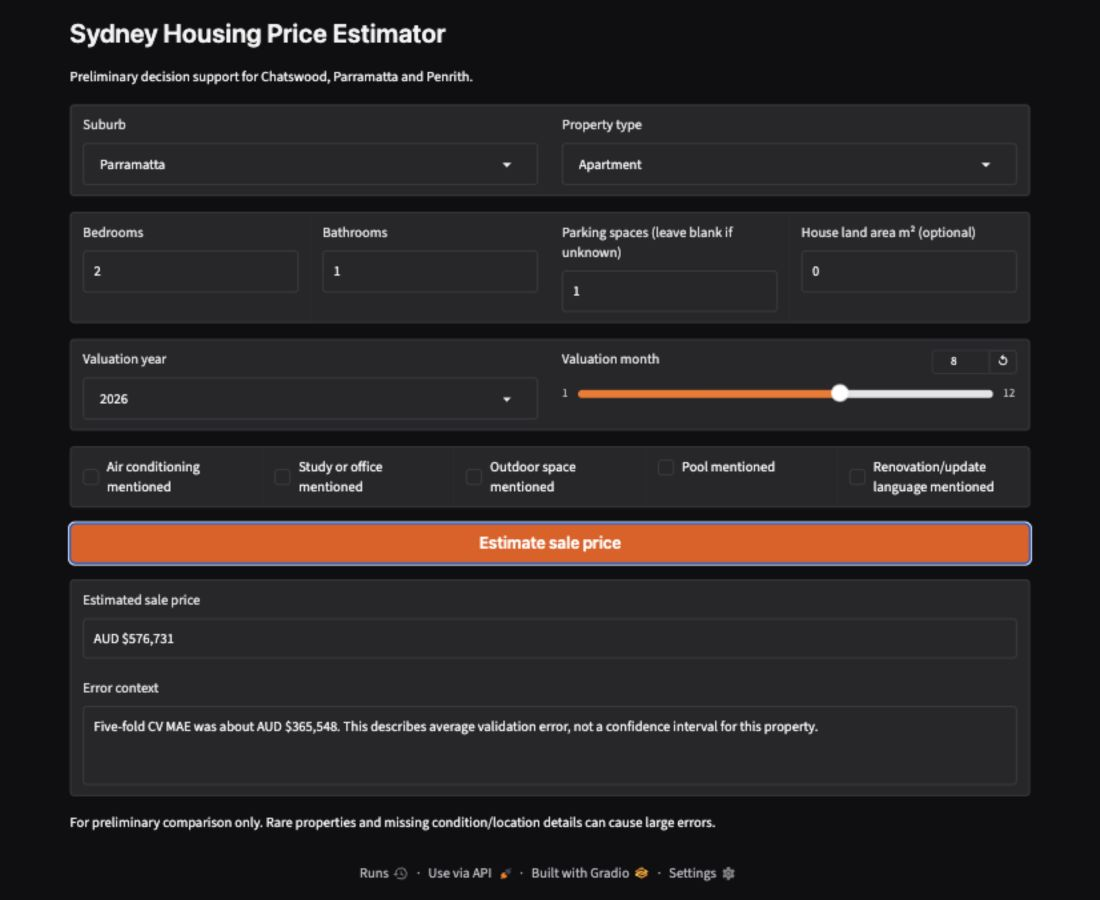

In [114]:
screenshot=MODEL_OUT/'app_screenshot.png'
if screenshot.exists():
    display(Image(filename=str(screenshot)))
else:
    print('Run the local app and save a screenshot to outputs/final/app_screenshot.png, then rerun this cell.')

### Critical reflection

The project demonstrates that data definition matters as much as algorithm choice. Manual collection exposed conflicting area labels, missing parking, promotional language and uneven time/type coverage. Separating land, living and title areas prevented false precision, while preserving flags kept unusual records auditable. Feature engineering remained conservative because 92 development cases cannot support a large set of weak proxies. This is consistent with evidence that data quality and granularity place a fundamental limit on automated valuation performance [3].

The tree-based models improved on the linear baseline, but the train–validation gaps and weak ten-property held-out result show that model complexity cannot compensate for limited comparables. The largest errors are rare Chatswood houses where heritage, development potential, condition and micro-location dominate simple counts. Earlier housing research similarly found that explicitly accounting for geography can reduce systematic prediction errors [1]. Deployment therefore presents error context and restricts the supported domain rather than offering an authoritative valuation. The Part 5 comparison also supports using models as decision aids: recent experimental evidence found that hybrid human–machine valuation can outperform either experts or an ML model working alone [2].

Automated valuations can reproduce representation bias: Parramatta apartments dominate their suburb, periods differ by suburb, and only disclosed prices are observed. Neighbourhood variables can proxy for socioeconomic status, and text descriptions reflect agents' selective marketing. Users could face unfair or misleading decisions if a point prediction is treated as a guarantee. Current AVM guidance therefore emphasises prediction uncertainty, bias auditing and governance rather than relying on point estimates alone [3]. The app should assist comparison and trigger further investigation, not determine lending, insurance, taxation or purchase decisions without professional evidence.

With more time and resources, I would collect a larger random or chronological sample with balanced dwelling types and matched periods; obtain verified internal area, coordinates, building age, strata costs, defects, planning and environmental data; use group/time-aware validation; quantify uncertainty; and monitor errors by suburb and type. A production system would also need versioned data, periodic backtesting, drift checks, authentication, privacy controls and a documented review/appeal process [3].


## References

[1] A. Caplin, S. Chopra, J. V. Leahy, Y. LeCun, and T. Thampy, “Machine learning and the spatial structure of house prices and housing returns,” SSRN Working Paper 1316046, Dec. 14, 2008, doi: 10.2139/ssrn.1316046.

[2] C. Kmen, G. Navratil, M. Kattenbeck, and I. Giannopoulos, “Evaluating human–machine collaboration through a comparative analysis of experts, machine learning, and hybrid approaches in real estate valuation,” *Scientific Reports*, vol. 16, Art. no. 4044, 2026, doi: 10.1038/s41598-025-34099-9.

[3] M. Despotovic, W. A. Brunauer, and D. Koch, “Data-driven real estate valuation, part II: Data, uncertainty and governance for reliable automated valuation models in practice,” *Journal of Property Investment & Finance*, early access, 2026, doi: 10.1108/JPIF-07-2026-0148.
